# Baseline Replication (Proper Calib/Test Split)

Replicates the consulting project (Hobelsberger 2026) UQ baseline results
in the agentic setting with **proper train/test methodology**.

**Capability:**
- Intelligently detects 50/50 calib/test split (results/ subdirectories)
- Falls back to legacy single-split mode if proper split not found
- MSP-Answer calibration uses separate held-out calibration set (no data leakage)
- All other metrics (StepCoCoA, BranchConsistency, CoCoA-Answer) remain comparable

**Research Question addressed:** RQ1 — Do existing UQ methods (MSP, CoCoA)
transfer reliably from static QA to multi-step agentic decision-making?

**Split mode detection:**
- If `results/{EXPERIMENT}/calib/` and `results/{EXPERIMENT}/test/` exist → Proper split mode ✓
- If only `results/{EXPERIMENT}/trajectories.jsonl` exists → Legacy mode (with warning)
- MSP-Answer uses msp_answer_level_proper(calib, test) in proper split mode
- MSP-Answer uses msp_answer_level(trajectories) in legacy mode (fits and evals on same data)

In [15]:
import sys
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path.cwd()))

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Ensure the repo root (which contains `uq/`) is on sys.path
repo_root = Path.cwd()
if not (repo_root / "uq").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from uq.evaluate import load_step_records, evaluate_step_uq, print_results_table
from uq.baselines import (
    load_trajectories_with_split,
    load_trajectories,
    msp_answer_level_proper,
    msp_answer_level,
    vce_answer_level,
    cocoa_answer_level
)

In [16]:
# Configure which experiment to analyse
EXPERIMENT = "gsm8k_cal_70B_500_split_50-50"  # or any results/<folder> for the 3 final benchmarks (gsm8k, agentbench_db, hotpotqa)
RESULTS_DIR = repo_root / "results" / EXPERIMENT

print(f"\n{'='*70}")
print(f"Loading trajectories from: {RESULTS_DIR}")
print(f"{'='*70}\n")

# Load data with intelligent split detection
try:
    calib_trajectories, test_trajectories, has_proper_split = load_trajectories_with_split(RESULTS_DIR)
except FileNotFoundError as e:
    print(f"❌ {e}")
    raise

# Load step records based on detected mode
if has_proper_split:
    # Proper split: evaluate on test set only
    test_traj_path = RESULTS_DIR / "test" / "trajectories.jsonl"
    steps = load_step_records(str(test_traj_path))
    trajectories = test_trajectories
    n_calib = len(calib_trajectories)
    # Retrieve split ratio from trajectory size from calib and test sets
    n_test = len(test_trajectories)
    split_ratio = n_calib / (n_calib + n_test) if (n_calib + n_test) > 0 else 0
    print(f"✅ Detected proper split with ratio: {split_ratio:.1%} calib / {1 - split_ratio:.1%} test")
    split_mode = f"proper split mode ({split_ratio:.1%} calib / {1 - split_ratio:.1%} test)"
else:
    # Legacy mode: use single trajectories
    single_traj_path = RESULTS_DIR / "trajectories.jsonl"
    steps = load_step_records(str(single_traj_path))
    trajectories = test_trajectories  # in legacy mode, these are all trajectories
    split_mode = "legacy single-split mode (fit and eval on same data)"
    n_calib = 0

n_steps = len(steps)
n_traj = len(trajectories)
success_rate = np.mean([t["task_success"] if "task_success" in t else False for t in trajectories])

print(f"✅ Split mode: {split_mode}")
print(f"✅ Loaded {n_steps} steps from {n_traj} test/eval trajectories")
if has_proper_split:
    print(f"✅ Calibration set: {n_calib} trajectories (held-out)")
print(f"✅ Task success rate: {success_rate:.1%} ({sum(1 for t in trajectories if t.get('task_success', False))}/{n_traj})")


Loading trajectories from: c:\Users\Chris\Documents\Python-Projects\CalibratedAgency\results\gsm8k_cal_70B_500_split_50-50

✅ Detected proper split with ratio: 50.0% calib / 50.0% test
✅ Split mode: proper split mode (50.0% calib / 50.0% test)
✅ Loaded 1911 steps from 250 test/eval trajectories
✅ Calibration set: 250 trajectories (held-out)
✅ Task success rate: 85.2% (213/250)


In [17]:
# --- Evaluate all methods ---
print(f"\n{'='*70}")
print("Evaluating UQ methods...")
if has_proper_split:
    print(f"(Using proper calib/test split for all metrics)")
else:
    print(f"(Using legacy single-split mode)")
print(f"{'='*70}\n")

results = {}

# Step-wise methods (proposed)
try:
    results["StepCoCoA"] = evaluate_step_uq(steps, confidence_key="c_star_cocoa", trajectories=trajectories)
    print("✅ StepCoCoA")
except Exception as e:
    print(f"⚠️  StepCoCoA failed: {e}")

try:
    results["BranchConsistency"] = evaluate_step_uq(steps, confidence_key="branch_consistency", trajectories=trajectories)
    print("✅ BranchConsistency")
except Exception as e:
    print(f"⚠️  BranchConsistency failed: {e}")

# NOT one of the thesis's four reported methods (quantile-clip normalized ablation of
# BranchConsistency) — computed separately, deliberately kept OUT of `results` so it can
# never appear in print_results_table(results) or any downstream table/plot.
try:
    branch_consistency_raw_diagnostic_only = evaluate_step_uq(steps, confidence_key="branch_consistency_raw", trajectories=trajectories)
    print("(diagnostic only, excluded from thesis) BranchConsistency-raw computed")
except Exception as e:
    print(f"⚠️  BranchConsistency-raw (diagnostic) failed: {e}")

# Answer-level baselines
try:
    if has_proper_split:
        # Proper split: fit on calib, evaluate on test (NO DATA LEAKAGE)
        msp_data, msp_params = msp_answer_level_proper(calib_trajectories, test_trajectories)
        results["MSP-Answer"] = evaluate_step_uq(msp_data, confidence_key="c_msp_answer", trajectories=trajectories)
        print(f"✅ MSP-Answer (proper split: q98={msp_params['q98']:.4f}, "
              f"u_min={msp_params['u_min']:.4f}, n_calib={msp_params['n_calib_samples']})")
    else:
        # Legacy mode: fit and evaluate on same data (with warning)
        msp_data = msp_answer_level(trajectories)
        results["MSP-Answer"] = evaluate_step_uq(msp_data, confidence_key="c_msp_answer", trajectories=trajectories)
        print("✅ MSP-Answer (legacy mode: fit and eval on same data)")
except Exception as e:
    print(f"⚠️  MSP-Answer failed: {e}")

try:
    vce_data = vce_answer_level(trajectories)
    if vce_data:
        results["VCE-Answer"] = evaluate_step_uq(vce_data, confidence_key="c_vce_answer", trajectories=trajectories)
        print("✅ VCE-Answer")
except Exception as e:
    print(f"⚠️  VCE-Answer failed: {e}")

try:
    # CoCoA-Answer: inherits calibration from final step's c_star_cocoa
    # (which uses proper split if available, or legacy otherwise)
    cocoa_data = cocoa_answer_level(trajectories)
    results["CoCoA-Answer"] = evaluate_step_uq(cocoa_data, confidence_key="c_cocoa_answer", trajectories=trajectories)
    if has_proper_split:
        print("✅ CoCoA-Answer (inherits calibration from step-level proper split)")
    else:
        print("✅ CoCoA-Answer (inherits calibration from step-level legacy mode)")
except Exception as e:
    print(f"⚠️  CoCoA-Answer failed: {e}")

# =========================================================================
# Print results table
# =========================================================================
print(f"\n{'='*70}")
print("Results Table")
print(f"{'='*70}\n")
print_results_table(results)


Evaluating UQ methods...
(Using proper calib/test split for all metrics)



✅ StepCoCoA
✅ BranchConsistency
(diagnostic only, excluded from thesis) BranchConsistency-raw computed
✅ MSP-Answer (proper split: q98=0.4936, u_min=0.0001, n_calib=250)
✅ CoCoA-Answer (inherits calibration from step-level proper split)

Results Table


Method                            ACC     ECE     AUROC    SelAcc@.8   Coverage 
--------------------------------------------------------------------------------
StepCoCoA                         0.852   0.118   0.722    0.890       0.811    
BranchConsistency                 0.852   0.064   0.677    0.898       0.785    
MSP-Answer                        0.852   0.128   0.638    0.879       0.956    
CoCoA-Answer                      0.852   0.132   0.692    0.866       0.984    



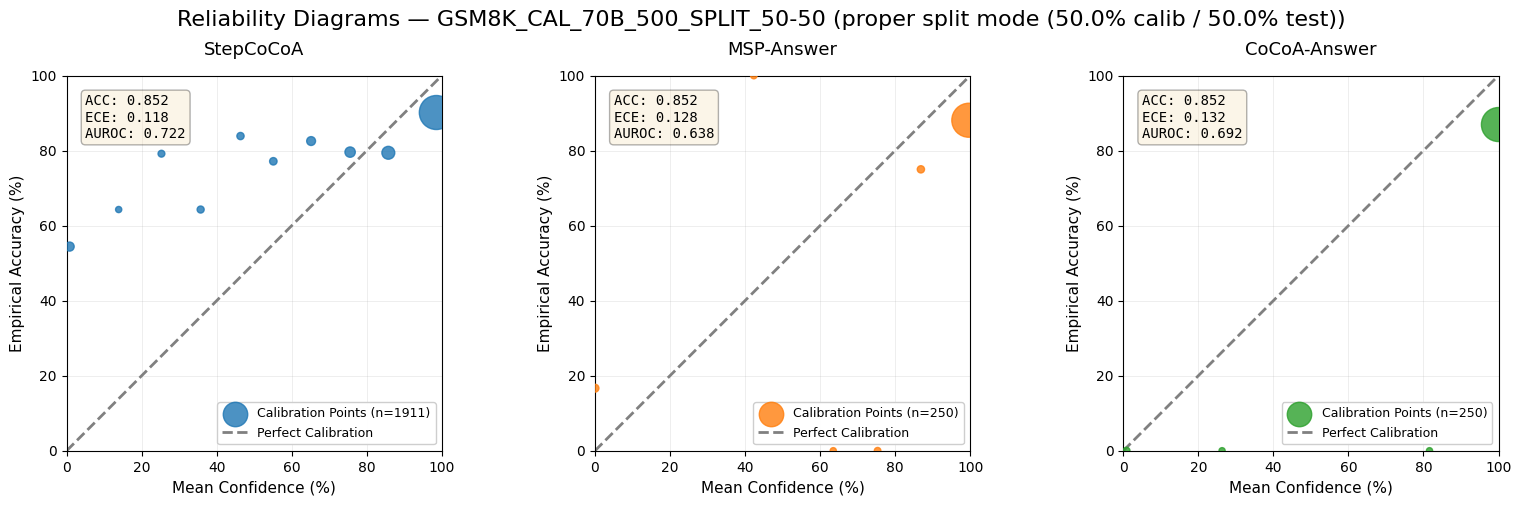

Saved to results/gsm8k_cal_70B_500_split_50-50/reliability_diagrams.png


In [18]:
# --- Reliability diagram ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Reliability Diagrams — {EXPERIMENT.upper()} ({split_mode})", fontsize=16, y=0.98)

# For MSP-Answer, we need to handle proper split vs legacy
if has_proper_split:
    msp_data_for_plot, _ = msp_answer_level_proper(calib_trajectories, test_trajectories)
else:
    msp_data_for_plot = msp_answer_level(trajectories)

methods = [
    ("StepCoCoA",     steps,                    "c_star_cocoa",   "C0"),
    ("MSP-Answer",    msp_data_for_plot,        "c_msp_answer",   "C1"),
    ("CoCoA-Answer",  cocoa_answer_level(trajectories), "c_cocoa_answer", "C2"),
]

N_BINS   = 10
MIN_BLOB = 20
MAX_BLOB = 600

for ax, (label, data, key, color) in zip(axes, methods):
    valid = [s for s in data if s.get(key) is not None and s.get("is_correct") is not None]
    if not valid:
        ax.set_title(f"{label}\n(no data)", fontsize=12)
        continue

    confs = np.array([s[key]               for s in valid], dtype=float) * 100.0
    corrs = np.array([int(s["is_correct"]) for s in valid], dtype=float)

    # --- manual binning with inclusive upper edge ---
    bin_edges = np.linspace(0, 100, N_BINS + 1)
    bin_edges[-1] += 1e-9
    df_v = pd.DataFrame({"conf": confs, "correct": corrs})
    df_v["bin"] = pd.cut(df_v["conf"], bins=bin_edges, right=False, include_lowest=True)

    calib = (
        df_v.groupby("bin", observed=True)
            .agg(mean_conf=("conf",    "mean"),
                 accuracy  =("correct", "mean"),
                 count     =("correct", "count"))
            .dropna()
    )

    # --- min-max blob sizing ---
    counts = calib["count"].values.astype(float)
    if counts.max() > counts.min():
        sizes = MIN_BLOB + (counts - counts.min()) / (counts.max() - counts.min()) * (MAX_BLOB - MIN_BLOB)
    else:
        sizes = np.full_like(counts, (MIN_BLOB + MAX_BLOB) / 2)

    ax.scatter(
        calib["mean_conf"],
        calib["accuracy"] * 100.0,
        s=sizes,
        color=color, alpha=0.8, zorder=3,
        label=f"Calibration Points (n={len(valid)})",
    )

    ax.plot([0, 100], [0, 100], "--", color="gray", linewidth=2,
            label="Perfect Calibration", zorder=2)

    ece   = results.get(label, {}).get("ece",      float("nan"))
    auroc = results.get(label, {}).get("auroc",    float("nan"))
    acc   = results.get(label, {}).get("accuracy", float("nan"))
    ax.text(0.05, 0.95,
            f"ACC: {acc:.3f}\nECE: {ece:.3f}\nAUROC: {auroc:.3f}",
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    ax.set_title(f"{label}", fontsize=13, pad=15)
    ax.set_xlabel("Mean Confidence (%)", fontsize=11)
    ax.set_ylabel("Empirical Accuracy (%)", fontsize=11)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_aspect('equal')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/reliability_diagrams.png",
            bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved to results/{EXPERIMENT}/reliability_diagrams.png")

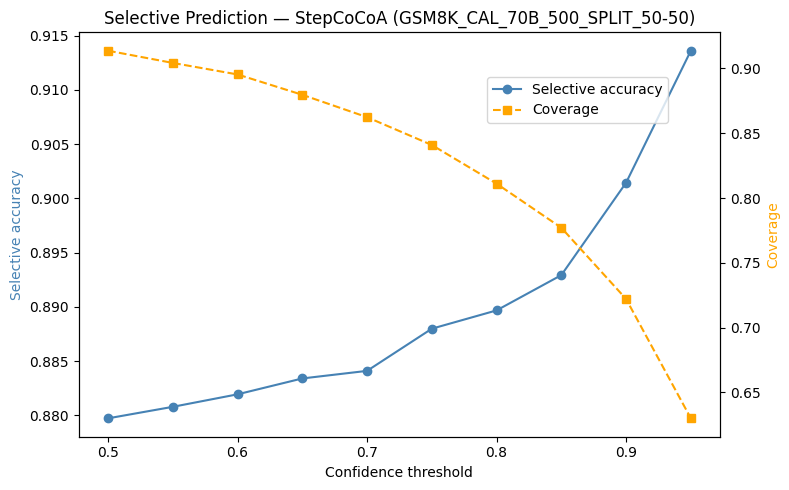

In [19]:
# --- Selective accuracy at various thresholds ---
thresholds = np.arange(0.5, 1.0, 0.05)

valid = [s for s in steps if s.get("c_star_cocoa") is not None and s.get("is_correct") is not None]
confs = np.array([s["c_star_cocoa"] for s in valid])
corrs = np.array([int(s["is_correct"]) for s in valid])

sel_accs   = [corrs[confs > t].mean() if (confs > t).any() else np.nan for t in thresholds]
coverages  = [(confs > t).mean() for t in thresholds]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
ax1.plot(thresholds, sel_accs, "o-", color="steelblue", label="Selective accuracy")
ax2.plot(thresholds, coverages, "s--", color="orange", label="Coverage")
ax1.set_xlabel("Confidence threshold")
ax1.set_ylabel("Selective accuracy", color="steelblue")
ax2.set_ylabel("Coverage", color="orange")
ax1.set_title(f"Selective Prediction — StepCoCoA ({EXPERIMENT.upper()})")
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/selective_accuracy.png", bbox_inches="tight")
plt.show()

In [20]:
# ============================================================================
# 1. STEP DISTRIBUTION ANALYSIS
# ============================================================================
print("\n=== STEP DISTRIBUTION ===")
n_steps_list = [t.get('n_steps', 0) for t in trajectories]
print(f"Mean steps/trajectory: {np.mean(n_steps_list):.2f}")
print(f"Median: {np.median(n_steps_list):.0f}")
print(f"Max: {np.max(n_steps_list)}")
print(f"Distribution:")
for n in range(1, max(n_steps_list) + 1):
    count = sum(1 for x in n_steps_list if x == n)
    if count > 0:
        print(f"  {n} step{'s' if n > 1 else ''}: {count} trajectories ({100*count/len(trajectories):.1f}%)")


=== STEP DISTRIBUTION ===
Mean steps/trajectory: 7.64
Median: 7
Max: 12
Distribution:
  3 steps: 1 trajectories (0.4%)
  4 steps: 3 trajectories (1.2%)
  5 steps: 73 trajectories (29.2%)
  6 steps: 3 trajectories (1.2%)
  7 steps: 72 trajectories (28.8%)
  8 steps: 4 trajectories (1.6%)
  9 steps: 40 trajectories (16.0%)
  10 steps: 3 trajectories (1.2%)
  11 steps: 25 trajectories (10.0%)
  12 steps: 26 trajectories (10.4%)


In [21]:
# ============================================================================
# 2. TOOL USE ANALYSIS
# ============================================================================
tool_use_count = sum(1 for t in trajectories if any('action_name' in step and step.get('action_name') in ['calculate', 'sql_query', 'list_tables', 'describe_table', 'sql_execute'] for step in t.get('trajectory', [])))
print(f"\n=== TOOL USE ===")
print(f"Trajectories with tool use: {tool_use_count}/{len(trajectories)} ({100*tool_use_count/len(trajectories):.1f}%)")


=== TOOL USE ===
Trajectories with tool use: 250/250 (100.0%)


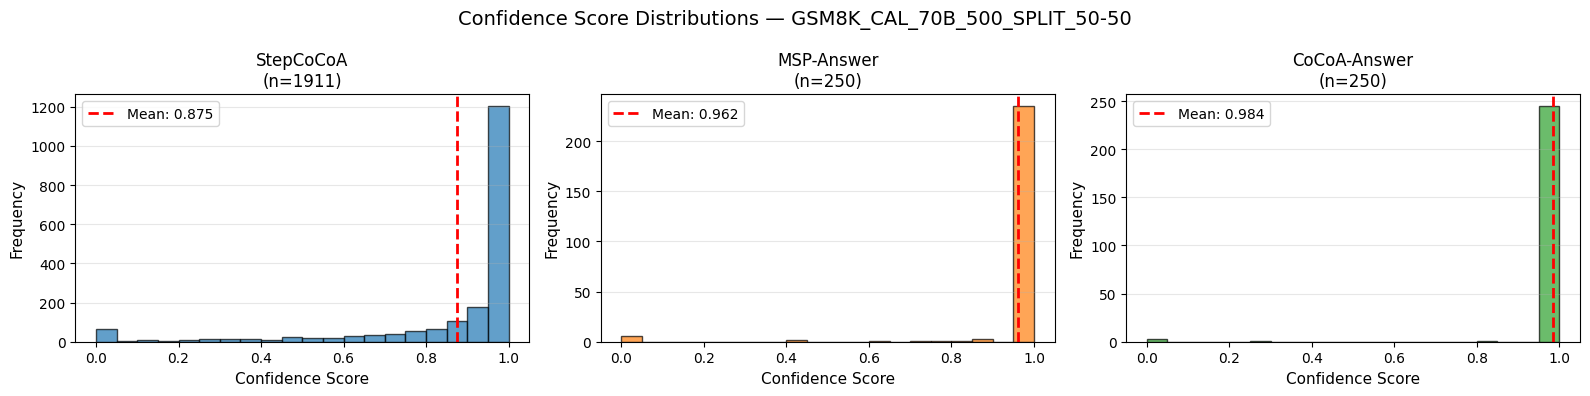

In [22]:
# ============================================================================
# 3. CONFIDENCE DISTRIBUTION
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Confidence Score Distributions — {EXPERIMENT.upper()}", fontsize=14)

confidence_keys = [
    ("StepCoCoA", "c_star_cocoa", "C0"),
    ("MSP-Answer", "c_msp_answer", "C1"),
    ("CoCoA-Answer", "c_cocoa_answer", "C2"),
]

for ax, (label, key, color) in zip(axes, confidence_keys):
    if label == "StepCoCoA":
        data = steps
    elif label == "MSP-Answer":
        if has_proper_split:
            data, _ = msp_answer_level_proper(calib_trajectories, test_trajectories)
        else:
            data = msp_answer_level(trajectories)
    else:
        data = cocoa_answer_level(trajectories)
    
    confs = [s[key] for s in data if s.get(key) is not None]
    
    if confs:
        ax.hist(confs, bins=20, color=color, alpha=0.7, edgecolor='black')
        ax.set_title(f"{label}\n(n={len(confs)})", fontsize=12)
        ax.set_xlabel("Confidence Score", fontsize=11)
        ax.set_ylabel("Frequency", fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')
        ax.axvline(np.mean(confs), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(confs):.3f}')
        ax.legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confidence_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

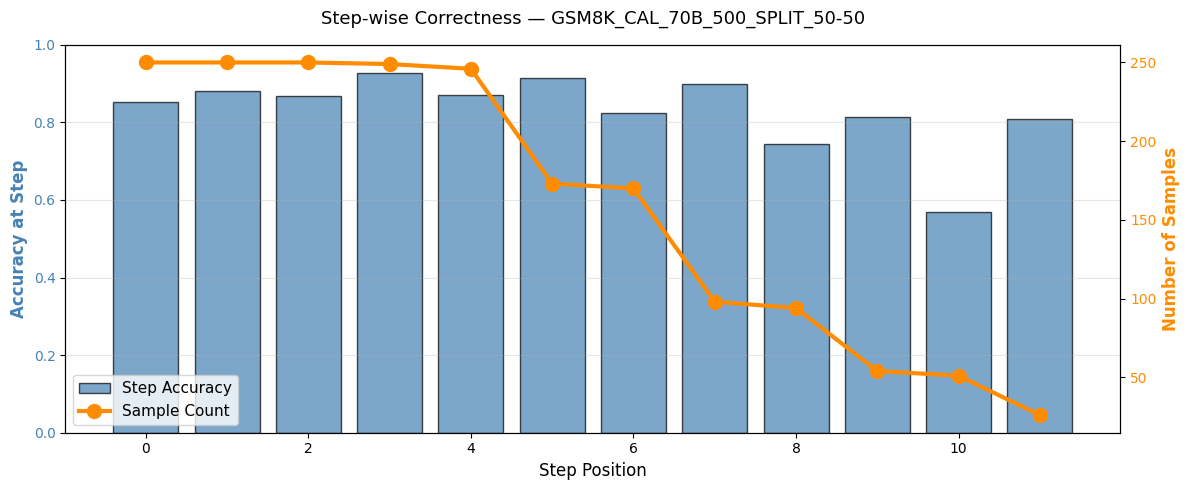

In [23]:
# ============================================================================
# 4. STEP CORRECTNESS ANALYSIS
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 5))

step_ids = [s.get('step_id', 0) for s in steps]
is_correct = [int(s.get('is_correct', 0)) for s in steps]

step_correctness = {}
for sid, correct in zip(step_ids, is_correct):
    if sid not in step_correctness:
        step_correctness[sid] = {'correct': 0, 'total': 0}
    step_correctness[sid]['total'] += 1
    step_correctness[sid]['correct'] += correct

steps_sorted = sorted(step_correctness.items())
step_nums = [s[0] for s in steps_sorted]
accuracies = [s[1]['correct'] / s[1]['total'] for s in steps_sorted]
counts = [s[1]['total'] for s in steps_sorted]

# Dual axis: accuracy (bar) and sample count (line)
ax2 = ax.twinx()

bars = ax.bar(step_nums, accuracies, color='steelblue', alpha=0.7, edgecolor='black', label='Step Accuracy')
line = ax2.plot(step_nums, counts, 'o-', color='darkorange', linewidth=3, markersize=10, label='Sample Count')

ax.set_xlabel("Step Position", fontsize=12)
ax.set_ylabel("Accuracy at Step", color='steelblue', fontsize=12, fontweight='bold')
ax2.set_ylabel("Number of Samples", color='darkorange', fontsize=12, fontweight='bold')
ax.set_title(f"Step-wise Correctness — {EXPERIMENT.upper()}", fontsize=13, pad=15)
ax.grid(True, alpha=0.3, axis='y', zorder=0)
ax.set_ylim([0, 1])
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=11)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/step_correctness.png", bbox_inches="tight", dpi=150)
plt.show()

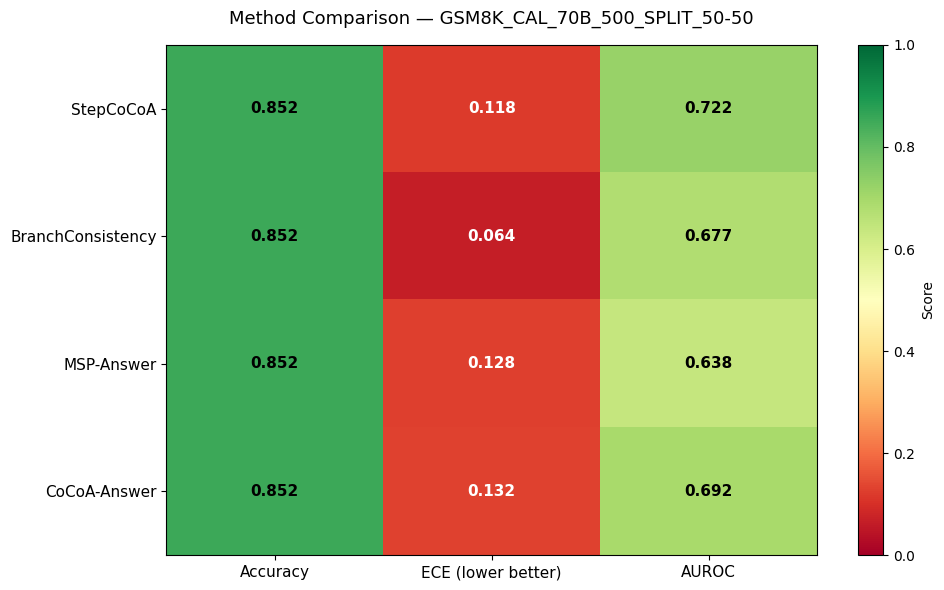

In [24]:
# ============================================================================
# 5. METHOD COMPARISON HEATMAP
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

method_names = list(results.keys())
metrics = ['accuracy', 'ece', 'auroc']
comparison_data = []

for method in method_names:
    row = [
        results[method].get('accuracy', np.nan),
        results[method].get('ece', np.nan),
        results[method].get('auroc', np.nan),
    ]
    comparison_data.append(row)

comparison_array = np.array(comparison_data)

# Create heatmap
im = ax.imshow(comparison_array, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

# Set ticks and labels
ax.set_xticks(range(len(metrics)))
ax.set_yticks(range(len(method_names)))
ax.set_xticklabels(['Accuracy', 'ECE (lower better)', 'AUROC'], fontsize=11)
ax.set_yticklabels(method_names, fontsize=11)

# Add values in cells
for i in range(len(method_names)):
    for j in range(len(metrics)):
        val = comparison_array[i, j]
        if not np.isnan(val):
            text = ax.text(j, i, f'{val:.3f}', ha="center", va="center", 
                          color="black" if val > 0.5 else "white", fontsize=11, fontweight='bold')

ax.set_title(f"Method Comparison — {EXPERIMENT.upper()}", fontsize=13, pad=15)
plt.colorbar(im, ax=ax, label='Score')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/method_comparison_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

In [25]:
# ============================================================================
# 6. BRANCHING CONSISTENCY DEEP DIVE
# ============================================================================

print("\n" + "="*70)
print("BRANCHCONSISTENCY ANALYSIS")
print("="*70)

branch_steps = [s for s in steps if s.get("branch_consistency") is not None and s.get("is_correct") is not None]
print(f"\nBranchConsistency coverage: {len(branch_steps)}/{len(steps)} ({100*len(branch_steps)/len(steps):.1f}%)")

if branch_steps:
    branch_confs = np.array([s["branch_consistency"] for s in branch_steps])
    branch_corrs = np.array([int(s["is_correct"]) for s in branch_steps])
    
    print(f"\nConfidence Statistics:")
    print(f"  Mean:     {np.mean(branch_confs):.3f}")
    print(f"  Std:      {np.std(branch_confs):.3f}")
    print(f"  Min:      {np.min(branch_confs):.3f}")
    print(f"  Max:      {np.max(branch_confs):.3f}")
    print(f"  Median:   {np.median(branch_confs):.3f}")
    
    print(f"\nCorrelation with Correctness:")
    corr_coeff = np.corrcoef(branch_confs, branch_corrs)[0, 1]
    print(f"  Pearson r: {corr_coeff:.3f}")
    
    # Accuracy at different confidence levels
    print(f"\nAccuracy by Confidence Level:")
    thresholds_bc = [0.0, 0.3, 0.5, 0.7, 0.9]
    for thresh in thresholds_bc:
        mask = branch_confs >= thresh
        if mask.any():
            acc = branch_corrs[mask].mean()
            count = mask.sum()
            print(f"  conf >= {thresh:.1f}: {acc:.3f} accuracy ({count} steps)")


BRANCHCONSISTENCY ANALYSIS

BranchConsistency coverage: 1911/1911 (100.0%)

Confidence Statistics:
  Mean:     0.857
  Std:      0.177
  Min:      0.092
  Max:      0.979
  Median:   0.942

Correlation with Correctness:
  Pearson r: 0.222

Accuracy by Confidence Level:
  conf >= 0.0: 0.861 accuracy (1911 steps)
  conf >= 0.3: 0.865 accuracy (1868 steps)
  conf >= 0.5: 0.877 accuracy (1776 steps)
  conf >= 0.7: 0.886 accuracy (1627 steps)
  conf >= 0.9: 0.908 accuracy (1258 steps)


Steps with both methods: 1911/1911 (100.0%)


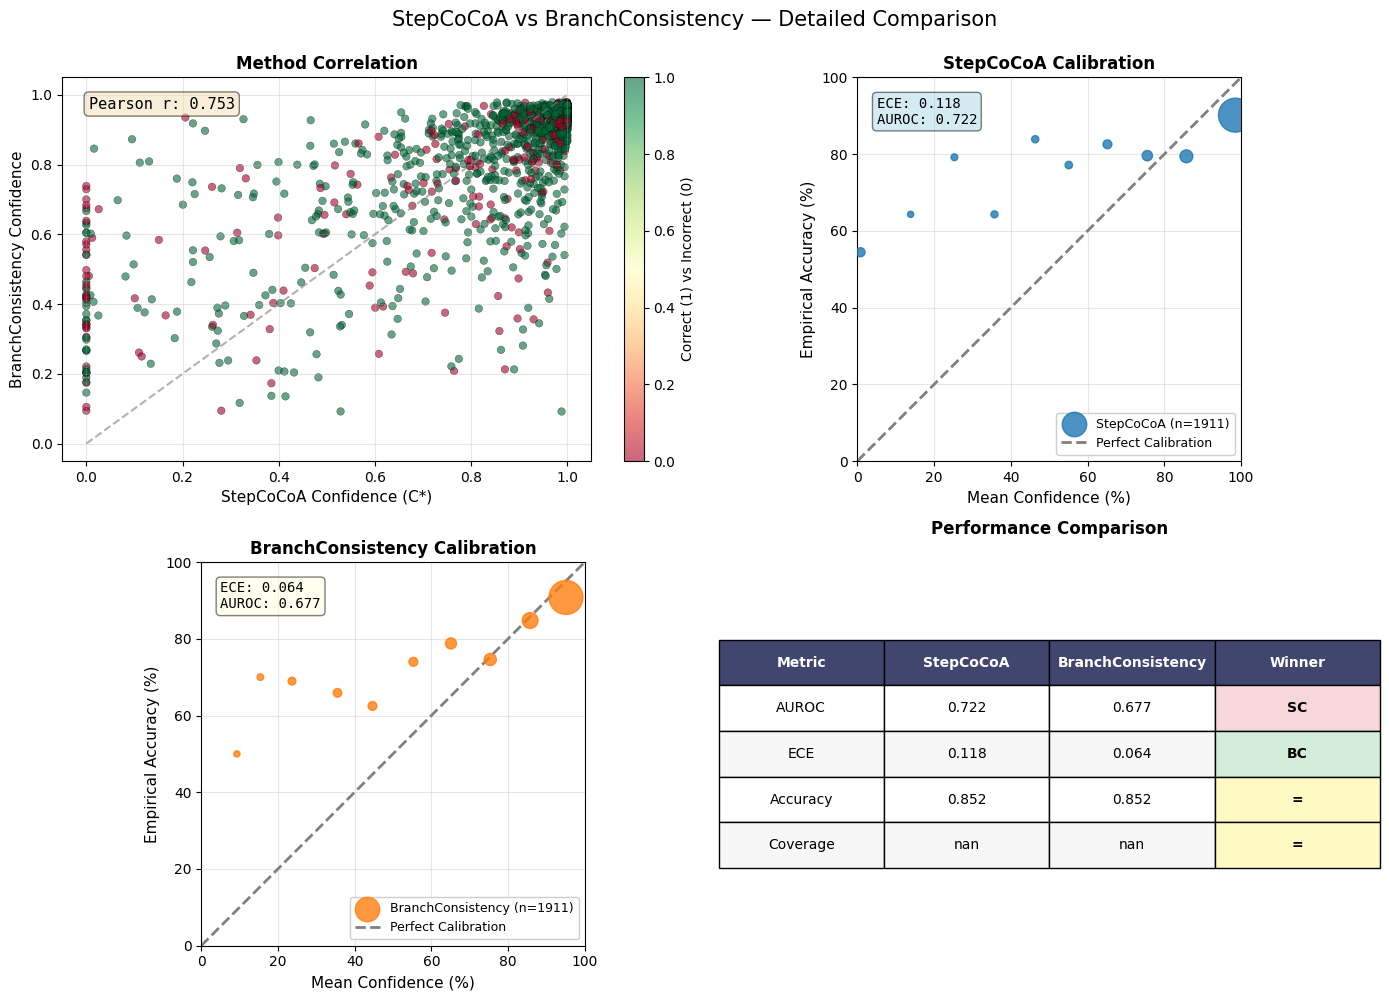

Saved to results/gsm8k_cal_70B_500_split_50-50/branchconsistency_vs_stepcocoa.png


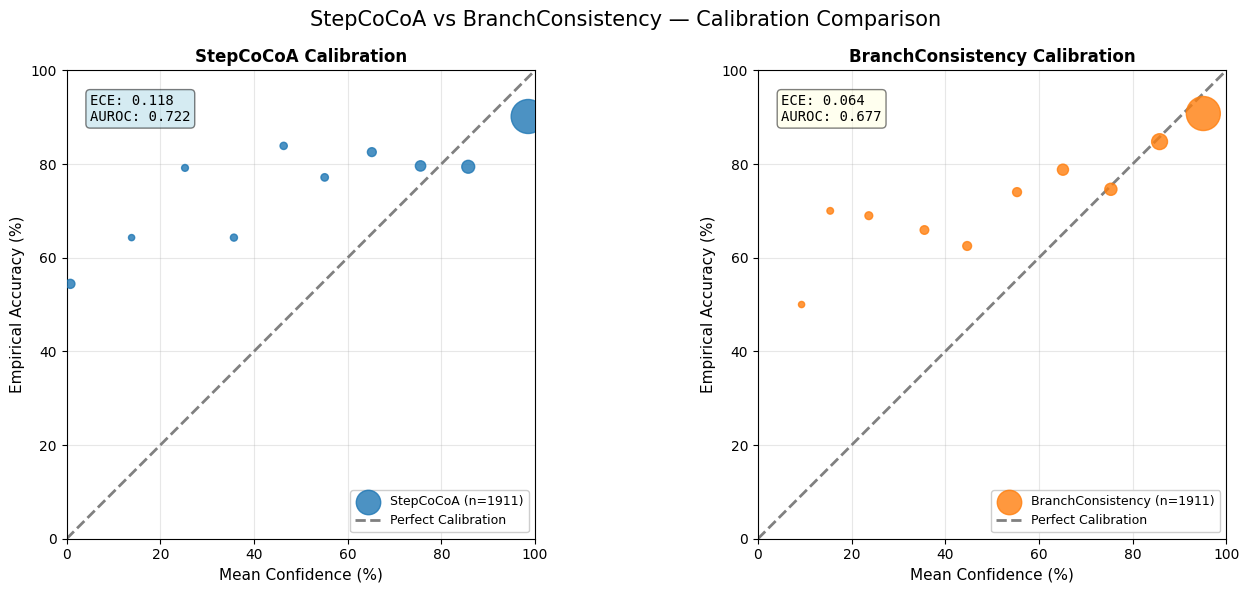

Saved to results/gsm8k_cal_70B_500_split_50-50/branchconsistency_vs_stepcocoa_calibration.png


In [26]:
# ============================================================================
# 7. BRANCHCONSISTENCY vs STEPCOCOA — DETAILED COMPARISON
# ============================================================================

N_BINS   = 10
MIN_BLOB = 20
MAX_BLOB = 600

def minmax_sizes(counts):
    counts = counts.astype(float)
    if counts.max() > counts.min():
        return MIN_BLOB + (counts - counts.min()) / (counts.max() - counts.min()) * (MAX_BLOB - MIN_BLOB)
    return np.full_like(counts, (MIN_BLOB + MAX_BLOB) / 2.0)

def blob_reliability(ax, confs_raw, corrs, color, label):
    """Manual-binned reliability diagram with min-max blob sizing."""
    confs = confs_raw * 100.0
    bin_edges = np.linspace(0, 100, N_BINS + 1)
    bin_edges[-1] += 1e-9
    df_v = pd.DataFrame({"conf": confs, "correct": corrs.astype(float)})
    df_v["bin"] = pd.cut(df_v["conf"], bins=bin_edges, right=False, include_lowest=True)
    calib = (
        df_v.groupby("bin", observed=True)
            .agg(mean_conf=("conf",    "mean"),
                 accuracy  =("correct", "mean"),
                 count     =("correct", "count"))
            .dropna()
    )
    ax.scatter(calib["mean_conf"], calib["accuracy"] * 100.0,
               s=minmax_sizes(calib["count"].values),
               color=color, alpha=0.8, zorder=3, label=label)
    ax.plot([0, 100], [0, 100], "--", color="gray", linewidth=2,
            label="Perfect Calibration", zorder=2)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_xlabel("Mean Confidence (%)", fontsize=11)
    ax.set_ylabel("Empirical Accuracy (%)", fontsize=11)
    ax.grid(True, alpha=0.3); ax.set_aspect('equal')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.95)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("StepCoCoA vs BranchConsistency — Detailed Comparison", fontsize=15, y=0.995)

cocoa_steps          = [s for s in steps if s.get("c_star_cocoa")       is not None and s.get("is_correct") is not None]
branch_steps_filtered = [s for s in steps if s.get("branch_consistency") is not None and s.get("is_correct") is not None]

common_steps = [s for s in steps
                if s.get("c_star_cocoa") is not None
                and s.get("branch_consistency") is not None
                and s.get("is_correct") is not None]
print(f"Steps with both methods: {len(common_steps)}/{len(steps)} ({100*len(common_steps)/len(steps):.1f}%)")

if common_steps:
    cocoa_confs  = np.array([s["c_star_cocoa"]       for s in common_steps])
    branch_confs = np.array([s["branch_consistency"] for s in common_steps])
    corrs        = np.array([int(s["is_correct"])    for s in common_steps])

    # --- Panel 1: Method Correlation ---
    ax = axes[0, 0]
    scatter = ax.scatter(cocoa_confs, branch_confs, c=corrs, cmap='RdYlGn',
                         alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
    # Identity line in the CoCoA [0,1] x branch range
    x_line = np.linspace(cocoa_confs.min(), cocoa_confs.max(), 100)
    ax.plot(x_line, x_line, "--", color="gray", linewidth=1.5,
            alpha=0.6, label="y = x", zorder=2)
    ax.set_xlabel("StepCoCoA Confidence (C*)", fontsize=11)
    ax.set_ylabel("BranchConsistency Confidence", fontsize=11)
    ax.set_title("Method Correlation", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Correct (1) vs Incorrect (0)", fontsize=10)
    method_corr = np.corrcoef(cocoa_confs, branch_confs)[0, 1]
    ax.text(0.05, 0.95, f"Pearson r: {method_corr:.3f}", transform=ax.transAxes,
            fontsize=11, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # --- Panel 2: StepCoCoA Reliability ---
    ax = axes[0, 1]
    if cocoa_steps:
        confs_c = np.array([s["c_star_cocoa"]    for s in cocoa_steps])
        corrs_c = np.array([int(s["is_correct"]) for s in cocoa_steps])
        blob_reliability(ax, confs_c, corrs_c, "C0",
                         f"StepCoCoA (n={len(cocoa_steps)})")
        ece_c = results["StepCoCoA"].get("ece", float("nan"))
        auroc_c = results["StepCoCoA"].get("auroc", float("nan"))
        ax.text(0.05, 0.95, f"ECE: {ece_c:.3f}\nAUROC: {auroc_c:.3f}", transform=ax.transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    ax.set_title("StepCoCoA Calibration", fontsize=12, fontweight='bold')

    # --- Panel 3: BranchConsistency Reliability ---
    # NOTE: branch_consistency is already normalized [0,1], use directly without sigmoid
    ax = axes[1, 0]
    if branch_steps_filtered:
        confs_b = np.array([s["branch_consistency"] for s in branch_steps_filtered]).astype(float)
        confs_b = np.nan_to_num(confs_b, nan=0.5, posinf=1.0, neginf=0.0)
        confs_b = np.clip(confs_b, 0.0, 1.0)
        corrs_b = np.array([int(s["is_correct"]) for s in branch_steps_filtered])
        blob_reliability(ax, confs_b, corrs_b, "C1",
                         f"BranchConsistency (n={len(branch_steps_filtered)})")
        ece_b = results["BranchConsistency"].get("ece", float("nan"))
        auroc_b = results["BranchConsistency"].get("auroc", float("nan"))
        ax.text(0.05, 0.95, f"ECE: {ece_b:.3f}\nAUROC: {auroc_b:.3f}", transform=ax.transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    ax.set_title("BranchConsistency Calibration", fontsize=12, fontweight='bold')

    # --- Panel 4: Metrics table ---
    ax = axes[1, 1]
    ax.axis('off')

    sc = results['StepCoCoA']
    bc = results['BranchConsistency']

    def winner(sc_val, bc_val, higher_is_better=True):
        if higher_is_better:
            return 'BC' if bc_val > sc_val else 'SC'
        else:
            return 'BC' if bc_val < sc_val else 'SC'

    metrics_data = [
        ['Metric',   'StepCoCoA',                              'BranchConsistency',                       'Winner'],
        ['AUROC',    f"{sc.get('auroc', float('nan')):.3f}",   f"{bc.get('auroc', float('nan')):.3f}",    winner(sc.get('auroc',0),   bc.get('auroc',0),  True)],
        ['ECE',      f"{sc.get('ece',   float('nan')):.3f}",   f"{bc.get('ece',   float('nan')):.3f}",    winner(sc.get('ece',1),     bc.get('ece',1),    False)],
        ['Accuracy', f"{sc.get('accuracy', float('nan')):.3f}",f"{bc.get('accuracy',float('nan')):.3f}",  '=' if abs(bc.get('accuracy',0)-sc.get('accuracy',0))<0.01 else winner(sc.get('accuracy',0),bc.get('accuracy',0))],
        ['Coverage', f"{sc.get('coverage', float('nan')):.3f}",f"{bc.get('coverage',float('nan')):.3f}",  '=' if abs(bc.get('coverage',0)-sc.get('coverage',0))<0.01 else 'Diff'],
    ]

    table = ax.table(cellText=metrics_data, cellLoc='center', loc='center',
                     colWidths=[0.25, 0.25, 0.25, 0.25])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.5)

    # Header
    for j in range(4):
        table[(0, j)].set_facecolor('#40466e')
        table[(0, j)].set_text_props(weight='bold', color='white')

    # Alternating rows + winner highlighting
    winner_colors = {'BC': '#d4edda', 'SC': '#f8d7da', '=': '#fff9c4', 'Diff': '#f0f0f0'}
    for i in range(1, len(metrics_data)):
        bg = '#f7f7f7' if i % 2 == 0 else 'white'
        for j in range(3):
            table[(i, j)].set_facecolor(bg)
        w = metrics_data[i][3]
        table[(i, 3)].set_facecolor(winner_colors.get(w, bg))
        table[(i, 3)].set_text_props(weight='bold')

    ax.set_title("Performance Comparison", fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/branchconsistency_vs_stepcocoa.png",
            bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved to results/{EXPERIMENT}/branchconsistency_vs_stepcocoa.png")

# Separate plot just covering panels 2 and 3 for better visibility
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("StepCoCoA vs BranchConsistency — Calibration Comparison", fontsize=15, y=0.98)
if cocoa_steps:
    confs_c = np.array([s["c_star_cocoa"]    for s in cocoa_steps])
    corrs_c = np.array([int(s["is_correct"]) for s in cocoa_steps])
    blob_reliability(axes[0], confs_c, corrs_c, "C0",
                     f"StepCoCoA (n={len(cocoa_steps)})")
    ece_c = results["StepCoCoA"].get("ece", float("nan"))
    auroc_c = results["StepCoCoA"].get("auroc", float("nan"))
    axes[0].text(0.05, 0.95, f"ECE: {ece_c:.3f}\nAUROC: {auroc_c:.3f}", transform=axes[0].transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    axes[0].set_title("StepCoCoA Calibration", fontsize=12, fontweight='bold')
if branch_steps_filtered:
    confs_b = np.array([s["branch_consistency"] for s in branch_steps_filtered]).astype(float)
    confs_b = np.nan_to_num(confs_b, nan=0.5, posinf=1.0, neginf=0.0)
    confs_b = np.clip(confs_b, 0.0, 1.0)
    corrs_b = np.array([int(s["is_correct"]) for s in branch_steps_filtered])
    blob_reliability(axes[1], confs_b, corrs_b, "C1",
                     f"BranchConsistency (n={len(branch_steps_filtered)})")
    ece_b = results["BranchConsistency"].get("ece", float("nan"))
    auroc_b = results["BranchConsistency"].get("auroc", float("nan"))
    axes[1].text(0.05, 0.95, f"ECE: {ece_b:.3f}\nAUROC: {auroc_b:.3f}", transform=axes[1].transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    axes[1].set_title("BranchConsistency Calibration", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/branchconsistency_vs_stepcocoa_calibration.png",
            bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved to results/{EXPERIMENT}/branchconsistency_vs_stepcocoa_calibration.png")

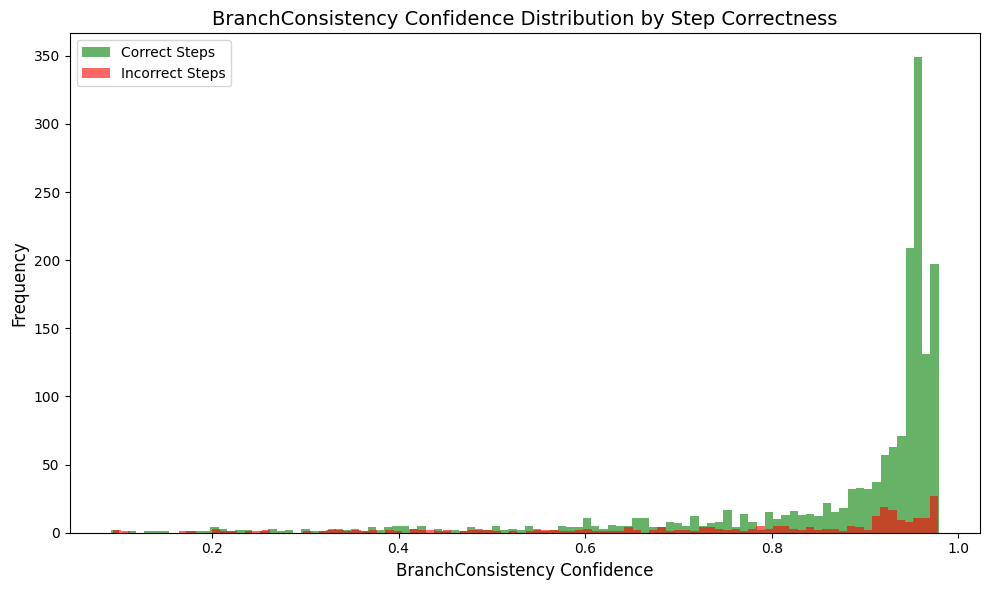

Saved histogram of BranchConsistency confidence distribution


<Figure size 640x480 with 0 Axes>

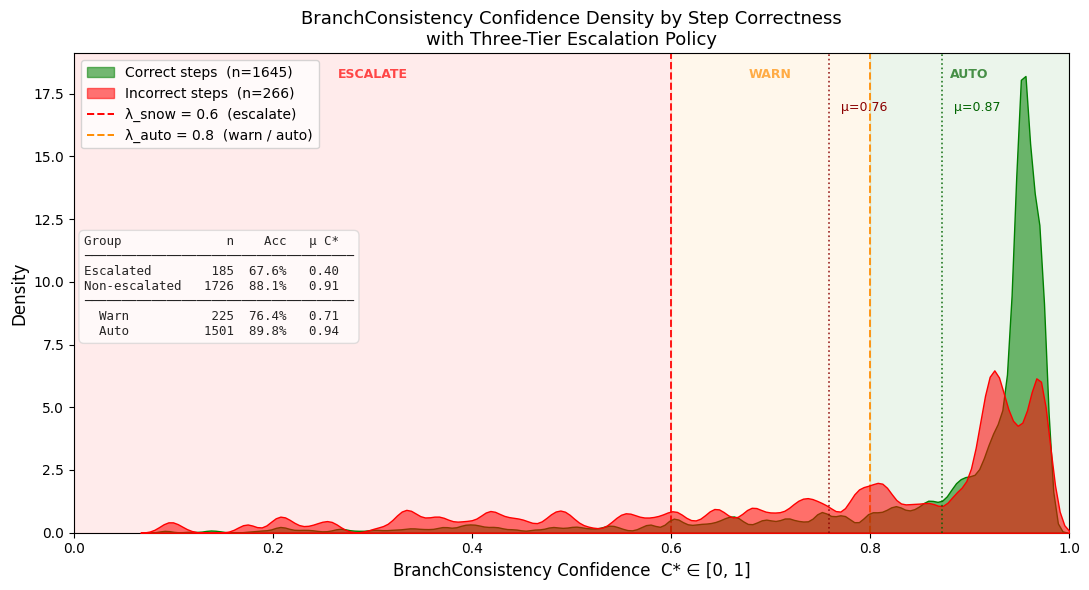

Saved KDE plot with escalation policy overlay


In [27]:
# Density plot of confidence scores for branch consistency, correctness vs incorrectness curves
if branch_steps_filtered:
    # NOTE: branch_consistency is already normalized [0,1], use directly without sigmoid
    confs_b = np.array([s["branch_consistency"] for s in branch_steps_filtered]).astype(float)
    confs_b = np.nan_to_num(confs_b, nan=0.5, posinf=1.0, neginf=0.0)
    confs_b = np.clip(confs_b, 0.0, 1.0)
    corrs_b = np.array([int(s["is_correct"]) for s in branch_steps_filtered])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(confs_b[corrs_b == 1], bins=100, color='green', alpha=0.6, label='Correct Steps')
    ax.hist(confs_b[corrs_b == 0], bins=100, color='red', alpha=0.6, label='Incorrect Steps')
    ax.set_xlabel("BranchConsistency Confidence", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("BranchConsistency Confidence Distribution by Step Correctness", fontsize=14)
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{RESULTS_DIR}/branchconsistency_confidence_distribution.png",
                bbox_inches="tight", dpi=150)
    print("Saved histogram of BranchConsistency confidence distribution")

if branch_steps_filtered:
    confs_b = np.array([s["branch_consistency"] for s in branch_steps_filtered]).astype(float)
    confs_b = np.nan_to_num(confs_b, nan=0.5, posinf=1.0, neginf=0.0)
    confs_b = np.clip(confs_b, 0.0, 1.0)
    corrs_b = np.array([int(s["is_correct"]) for s in branch_steps_filtered])

    # ── Escalation thresholds (match thesis Section 4.1.4) ────────────────────
    LAMBDA_SNOW = 0.6   # below → escalate
    LAMBDA_AUTO = 0.8   # above → auto-execute; between → warn

    fig, ax = plt.subplots(figsize=(11, 6))

    # ── 1. Policy zone shading (drawn first, behind everything) ───────────────
    zone_alpha = 0.08
    ax.axvspan(0.0,         LAMBDA_SNOW, color="red",    alpha=zone_alpha, zorder=0)
    ax.axvspan(LAMBDA_SNOW, LAMBDA_AUTO, color="orange", alpha=zone_alpha, zorder=0)
    ax.axvspan(LAMBDA_AUTO, 1.0,         color="green",  alpha=zone_alpha, zorder=0)

    # ── 2. Threshold lines ────────────────────────────────────────────────────
    for thresh, label, color in [
        (LAMBDA_SNOW, f"λ_snow = {LAMBDA_SNOW}  (escalate)", "red"),
        (LAMBDA_AUTO, f"λ_auto = {LAMBDA_AUTO}  (warn / auto)", "darkorange"),
    ]:
        ax.axvline(thresh, color=color, linestyle="--", linewidth=1.4, alpha=0.9, zorder=2)

    # ── 3. KDE curves ─────────────────────────────────────────────────────────
    bw = 0.04  # fixed bandwidth — keep identical across models for comparability
    sns.kdeplot(
        confs_b[corrs_b == 1], fill=True, color="green", alpha=0.55,
        label=f"Correct steps  (n={int((corrs_b==1).sum())})",
        bw_method=bw, clip=(0.0, 1.0), ax=ax, zorder=3
    )
    sns.kdeplot(
        confs_b[corrs_b == 0], fill=True, color="red", alpha=0.55,
        label=f"Incorrect steps  (n={int((corrs_b==0).sum())})",
        bw_method=bw, clip=(0.0, 1.0), ax=ax, zorder=3
    )

    # ── 4. Group mean lines ───────────────────────────────────────────────────
    y_top = ax.get_ylim()[1]
    for mask, color in [(corrs_b == 1, "darkgreen"), (corrs_b == 0, "darkred")]:
        mean_val = confs_b[mask].mean()
        ax.axvline(mean_val, color=color, linestyle=":", linewidth=1.2, alpha=0.85, zorder=4)
        ax.text(mean_val + 0.012, y_top * 0.88,
                f"μ={mean_val:.2f}", color=color, fontsize=9, zorder=5)

    # ── 5. Zone labels (top of chart) ─────────────────────────────────────────
    y_label = y_top * 0.97
    for x_mid, label, color in [
        ((0.0 + LAMBDA_SNOW) / 2,          "ESCALATE",  "red"),
        ((LAMBDA_SNOW + LAMBDA_AUTO) / 2,  "WARN",      "darkorange"),
        ((LAMBDA_AUTO + 1.0) / 2,          "AUTO",      "darkgreen"),
    ]:
        ax.text(x_mid, y_label, label, ha="center", va="top",
                fontsize=9, fontweight="bold", color=color,
                alpha=0.7, zorder=5)

    # ── 6. Escalation rate + outcome annotation ───────────────────────────────
    esc_mask  = confs_b < LAMBDA_SNOW
    warn_mask = (confs_b >= LAMBDA_SNOW) & (confs_b < LAMBDA_AUTO)
    auto_mask = confs_b >= LAMBDA_AUTO

    esc_rate  = esc_mask.mean()
    warn_rate = warn_mask.mean()
    auto_rate = auto_mask.mean()

    # Accuracy within each tier (guard against empty tiers)
    def tier_acc(mask):
        return corrs_b[mask].mean() if mask.sum() > 0 else float("nan")

    esc_acc  = tier_acc(esc_mask)
    warn_acc = tier_acc(warn_mask)
    auto_acc = tier_acc(auto_mask)

    # ── Escalated vs non-escalated aggregation ────────────────────────────────
    non_esc_mask = ~esc_mask  # warn + auto combined

    def group_stats(mask):
        if mask.sum() == 0:
            return {"n": 0, "acc": float("nan"), "mean_conf": float("nan")}
        return {
            "n":         int(mask.sum()),
            "acc":       float(corrs_b[mask].mean()),
            "mean_conf": float(confs_b[mask].mean()),
        }

    esc_stats     = group_stats(esc_mask)
    non_esc_stats = group_stats(non_esc_mask)

    annotation = (
        f"{'Group':<14} {'n':>5}  {'Acc':>5}  {'μ C*':>5}\n"
        f"{'─'*36}\n"
        f"{'Escalated':<14} {esc_stats['n']:>5}  {esc_stats['acc']:>5.1%}  {esc_stats['mean_conf']:>5.2f}\n"
        f"{'Non-escalated':<14} {non_esc_stats['n']:>5}  {non_esc_stats['acc']:>5.1%}  {non_esc_stats['mean_conf']:>5.2f}\n"
        f"{'─'*36}\n"
        f"{'  Warn':<14} {warn_mask.sum():>5}  {warn_acc:>5.1%}  {confs_b[warn_mask].mean():>5.2f}\n"
        f"{'  Auto':<14} {auto_mask.sum():>5}  {auto_acc:>5.1%}  {confs_b[auto_mask].mean():>5.2f}"
    )

    ax.text(0.01, y_top * 0.62,
            annotation, fontsize=9, color="black", alpha=0.85,
            family="monospace", va="top", zorder=5,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.7, ec="lightgrey"))
    
    # ── 7. Formatting ─────────────────────────────────────────────────────────
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("BranchConsistency Confidence  C* ∈ [0, 1]", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title("BranchConsistency Confidence Density by Step Correctness\n"
                 "with Three-Tier Escalation Policy", fontsize=13)

    # Combined legend: KDE + threshold lines
    legend_handles = [
        Patch(color="green",     alpha=0.55, label=f"Correct steps  (n={int((corrs_b==1).sum())})"),
        Patch(color="red",       alpha=0.55, label=f"Incorrect steps  (n={int((corrs_b==0).sum())})"),
        Line2D([0],[0], color="red",        linestyle="--", lw=1.4, label=f"λ_snow = {LAMBDA_SNOW}  (escalate)"),
        Line2D([0],[0], color="darkorange", linestyle="--", lw=1.4, label=f"λ_auto = {LAMBDA_AUTO}  (warn / auto)"),
    ]
    ax.legend(handles=legend_handles, fontsize=10, loc="upper left")

    plt.tight_layout()
    plt.savefig(
        f"{RESULTS_DIR}/branchconsistency_confidence_density.png",
        bbox_inches="tight", dpi=150
    )
    plt.show()
    print("Saved KDE plot with escalation policy overlay")

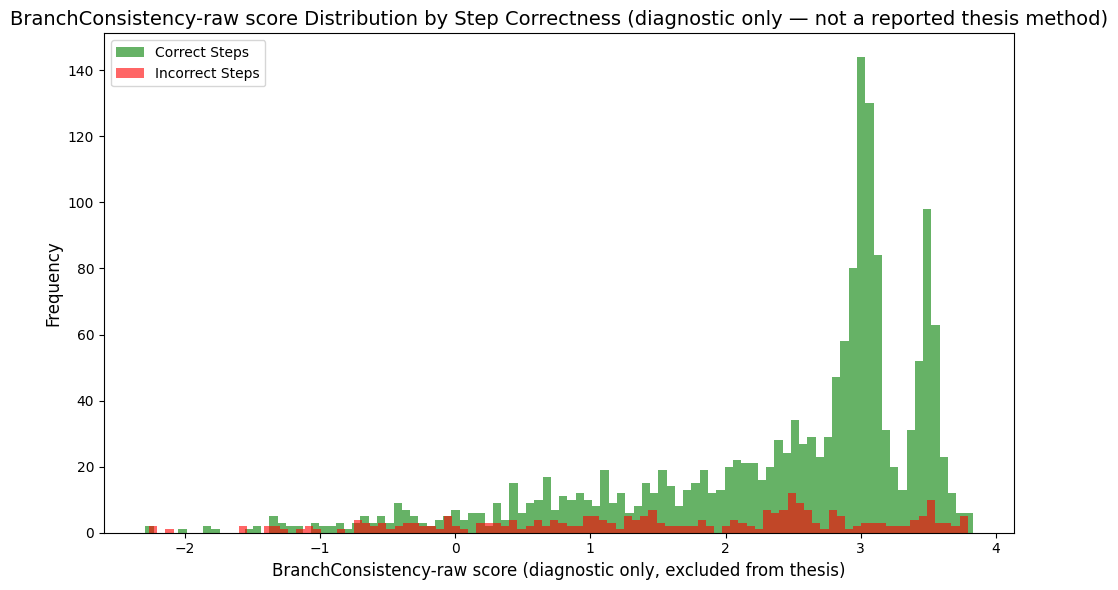

Saved histogram of BranchConsistency confidence distribution


<Figure size 640x480 with 0 Axes>

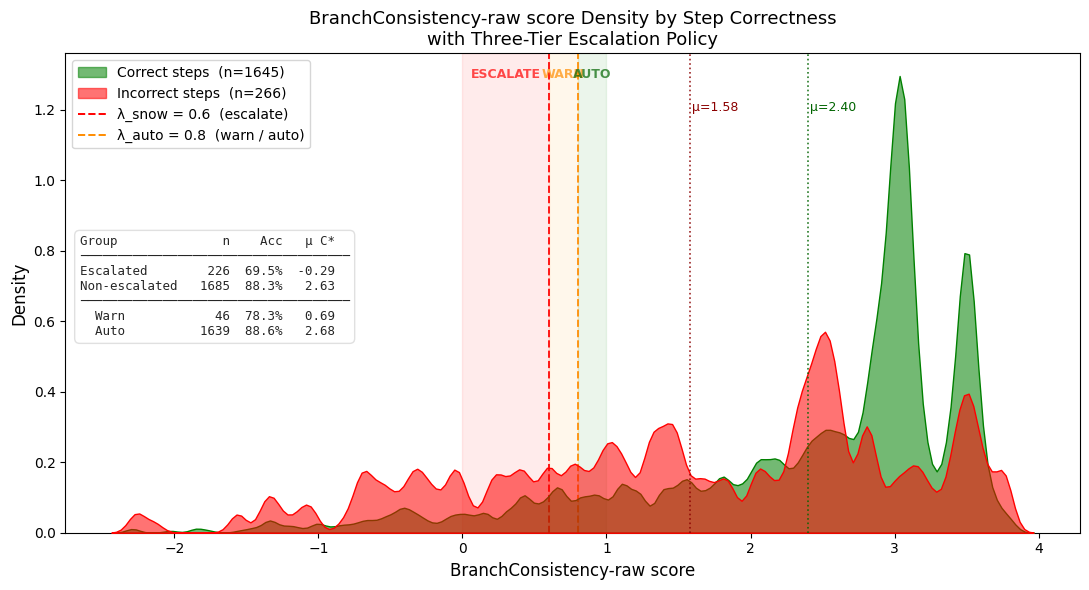

Saved KDE plot with escalation policy overlay


In [29]:
# Density plot of confidence scores for branch consistency raw, correctness vs incorrectness curves
if branch_steps_filtered:
    # NOTE: branch_consistency_raw is already normalized [0,1], use directly without sigmoid
    confs_b_raw = np.array([s["branch_consistency_raw"] for s in branch_steps_filtered]).astype(float)
    confs_b_raw = np.nan_to_num(confs_b_raw, nan=0.5, posinf=1.0, neginf=0.0)
    corrs_b_raw = np.array([int(s["is_correct"]) for s in branch_steps_filtered])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(confs_b_raw[corrs_b_raw == 1], bins=100, color='green', alpha=0.6, label='Correct Steps')
    ax.hist(confs_b_raw[corrs_b_raw == 0], bins=100, color='red', alpha=0.6, label='Incorrect Steps')
    ax.set_xlabel("BranchConsistency-raw score (diagnostic only, excluded from thesis)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("BranchConsistency-raw score Distribution by Step Correctness (diagnostic only — not a reported thesis method)", fontsize=14)
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{RESULTS_DIR}/branchconsistency_confidence_distribution.png",
                bbox_inches="tight", dpi=150)
    print("Saved histogram of BranchConsistency confidence distribution")

if branch_steps_filtered:
    confs_b_raw = np.array([s["branch_consistency_raw"] for s in branch_steps_filtered]).astype(float)
    confs_b_raw = np.nan_to_num(confs_b_raw, nan=0.5, posinf=1.0, neginf=0.0)
    corrs_b_raw = np.array([int(s["is_correct"]) for s in branch_steps_filtered])

    # ── Escalation thresholds (match thesis Section 4.1.4) ────────────────────
    LAMBDA_SNOW = 0.6   # below → escalate
    LAMBDA_AUTO = 0.8   # above → auto-execute; between → warn

    fig, ax = plt.subplots(figsize=(11, 6))

    # ── 1. Policy zone shading (drawn first, behind everything) ───────────────
    zone_alpha = 0.08
    ax.axvspan(0.0,         LAMBDA_SNOW, color="red",    alpha=zone_alpha, zorder=0)
    ax.axvspan(LAMBDA_SNOW, LAMBDA_AUTO, color="orange", alpha=zone_alpha, zorder=0)
    ax.axvspan(LAMBDA_AUTO, 1.0,         color="green",  alpha=zone_alpha, zorder=0)

    # ── 2. Threshold lines ────────────────────────────────────────────────────
    for thresh, label, color in [
        (LAMBDA_SNOW, f"λ_snow = {LAMBDA_SNOW}  (escalate)", "red"),
        (LAMBDA_AUTO, f"λ_auto = {LAMBDA_AUTO}  (warn / auto)", "darkorange"),
    ]:
        ax.axvline(thresh, color=color, linestyle="--", linewidth=1.4, alpha=0.9, zorder=2)

    # ── 3. KDE curves ─────────────────────────────────────────────────────────
    bw_raw = 0.04  # fixed bandwidth — keep identical across models for comparability
    sns.kdeplot(
        confs_b_raw[corrs_b_raw == 1], fill=True, color="green", alpha=0.55,
        label=f"Correct steps  (n={int((corrs_b_raw==1).sum())})",
        bw_method=bw_raw, ax=ax, zorder=3
    )
    sns.kdeplot(
        confs_b_raw[corrs_b_raw == 0], fill=True, color="red", alpha=0.55,
        label=f"Incorrect steps  (n={int((corrs_b_raw==0).sum())})",
        bw_method=bw_raw, ax=ax, zorder=3
    )

    # ── 4. Group mean lines ───────────────────────────────────────────────────
    y_top = ax.get_ylim()[1]
    for mask, color in [(corrs_b_raw == 1, "darkgreen"), (corrs_b_raw == 0, "darkred")]:
        mean_val = confs_b_raw[mask].mean()
        ax.axvline(mean_val, color=color, linestyle=":", linewidth=1.2, alpha=0.85, zorder=4)
        ax.text(mean_val + 0.012, y_top * 0.88,
                f"μ={mean_val:.2f}", color=color, fontsize=9, zorder=5)

    # ── 5. Zone labels (top of chart) ─────────────────────────────────────────
    y_label = y_top * 0.97
    for x_mid, label, color in [
        ((0.0 + LAMBDA_SNOW) / 2,          "ESCALATE",  "red"),
        ((LAMBDA_SNOW + LAMBDA_AUTO) / 2,  "WARN",      "darkorange"),
        ((LAMBDA_AUTO + 1.0) / 2,          "AUTO",      "darkgreen"),
    ]:
        ax.text(x_mid, y_label, label, ha="center", va="top",
                fontsize=9, fontweight="bold", color=color,
                alpha=0.7, zorder=5)

    # ── 6. Escalation rate + outcome annotation ───────────────────────────────
    esc_mask_raw  = confs_b_raw < LAMBDA_SNOW
    warn_mask_raw = (confs_b_raw >= LAMBDA_SNOW) & (confs_b_raw < LAMBDA_AUTO)
    auto_mask_raw = confs_b_raw >= LAMBDA_AUTO

    esc_rate_raw  = esc_mask_raw.mean()
    warn_rate_raw = warn_mask_raw.mean()
    auto_rate_raw = auto_mask_raw.mean()

    # Accuracy within each tier (guard against empty tiers)
    def tier_acc(mask):
        return corrs_b_raw[mask].mean() if mask.sum() > 0 else float("nan")

    esc_acc_raw  = tier_acc(esc_mask_raw)
    warn_acc_raw = tier_acc(warn_mask_raw)
    auto_acc_raw = tier_acc(auto_mask_raw)

    # ── Escalated vs non-escalated aggregation ────────────────────────────────
    non_esc_mask_raw = ~esc_mask_raw  # warn + auto combined

    def group_stats(mask):
        if mask.sum() == 0:
            return {"n": 0, "acc": float("nan"), "mean_conf": float("nan")}
        return {
            "n":         int(mask.sum()),
            "acc":       float(corrs_b_raw[mask].mean()),
            "mean_conf": float(confs_b_raw[mask].mean()),
        }

    esc_stats_raw     = group_stats(esc_mask_raw)
    non_esc_stats_raw = group_stats(non_esc_mask_raw)

    annotation_raw = (
        f"{'Group':<14} {'n':>5}  {'Acc':>5}  {'μ C*':>5}\n"
        f"{'─'*36}\n"
        f"{'Escalated':<14} {esc_stats_raw['n']:>5}  {esc_stats_raw['acc']:>5.1%}  {esc_stats_raw['mean_conf']:>5.2f}\n"
        f"{'Non-escalated':<14} {non_esc_stats_raw['n']:>5}  {non_esc_stats_raw['acc']:>5.1%}  {non_esc_stats_raw['mean_conf']:>5.2f}\n"
        f"{'─'*36}\n"
        f"{'  Warn':<14} {warn_mask_raw.sum():>5}  {warn_acc_raw:>5.1%}  {confs_b_raw[warn_mask_raw].mean():>5.2f}\n"
        f"{'  Auto':<14} {auto_mask_raw.sum():>5}  {auto_acc_raw:>5.1%}  {confs_b_raw[auto_mask_raw].mean():>5.2f}"
    )
    x_min = ax.get_xlim()[0]
    ax.text(x_min + 0.1, y_top * 0.62,
            annotation_raw, fontsize=9, color="black", alpha=0.85,
            family="monospace", va="top", zorder=5,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.7, ec="lightgrey"))
    
    # ── 7. Formatting ─────────────────────────────────────────────────────────
    ax.set_xlabel("BranchConsistency-raw score", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title("BranchConsistency-raw score Density by Step Correctness\n"
                 "with Three-Tier Escalation Policy", fontsize=13)

    # Combined legend: KDE + threshold lines
    legend_handles = [
        Patch(color="green",     alpha=0.55, label=f"Correct steps  (n={int((corrs_b_raw==1).sum())})"),
        Patch(color="red",       alpha=0.55, label=f"Incorrect steps  (n={int((corrs_b_raw==0).sum())})"),
        Line2D([0],[0], color="red",        linestyle="--", lw=1.4, label=f"λ_snow = {LAMBDA_SNOW}  (escalate)"),
        Line2D([0],[0], color="darkorange", linestyle="--", lw=1.4, label=f"λ_auto = {LAMBDA_AUTO}  (warn / auto)"),
    ]
    ax.legend(handles=legend_handles, fontsize=10, loc="upper left")

    plt.savefig(
        f"{RESULTS_DIR}/branchconsistency_raw_confidence_density.png",
        bbox_inches="tight", dpi=150
    )
    plt.tight_layout()
    plt.show()
    print("Saved KDE plot with escalation policy overlay")


ESCALATION EFFECTIVENESS ANALYSIS

Total escalations: 185/1911 (9.7%)
Escalated steps that were correct: 125/185 (67.6%)
Escalated steps that were incorrect: 60/185 (32.4%)

Non-escalated steps that were correct: 1520/1726 (88.1%)
Non-escalated steps that were incorrect: 206/1726 (11.9%)

Interpretation:
  - Low escalation rate suggests most steps have high agreement
  - When escalation occurs, it should be on uncertain/difficult steps
  - Escalated steps being mostly CORRECT suggests:
    * Escalation is conservative (only on very uncertain steps)
    * Those steps would likely succeed anyway
    * Escalation signal for when to ask for human help


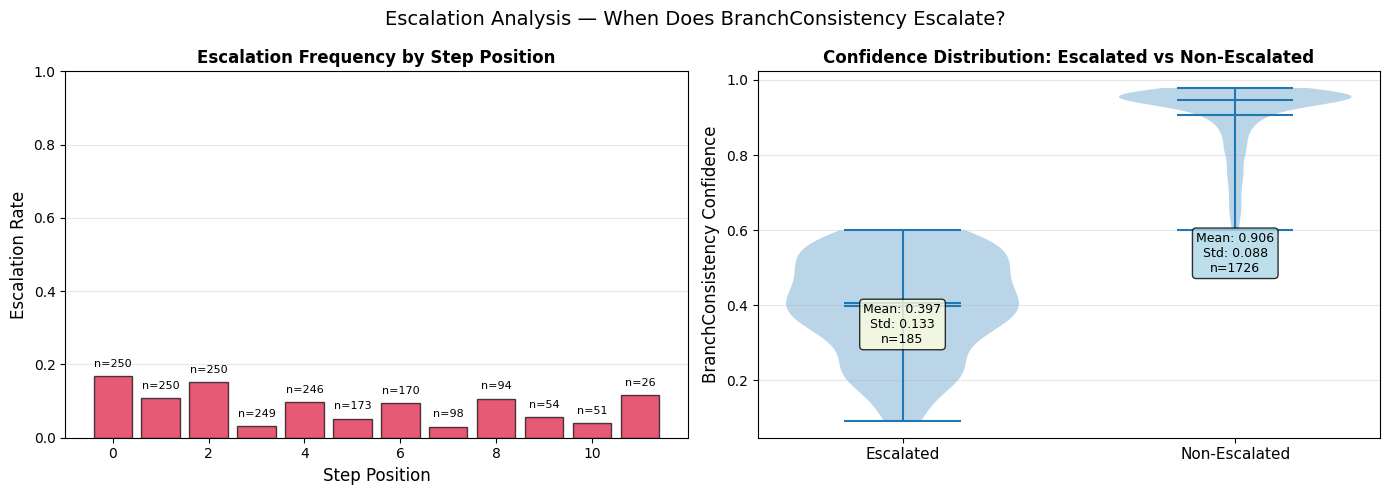


Saved to results/gsm8k_cal_70B_500_split_50-50/escalation_analysis.png


In [30]:
# ============================================================================
# 8. ESCALATION ANALYSIS — WHEN DO METHODS TRIGGER ESCALATION?
# ============================================================================

print("\n" + "="*70)
print("ESCALATION EFFECTIVENESS ANALYSIS")
print("="*70)

escalated_steps = [s for s in steps if s.get("escalated", False)]
print(f"\nTotal escalations: {len(escalated_steps)}/{len(steps)} ({100*len(escalated_steps)/len(steps):.1f}%)")

if escalated_steps:
    escalated_correct = sum(1 for s in escalated_steps if s.get("is_correct"))
    print(f"Escalated steps that were correct: {escalated_correct}/{len(escalated_steps)} ({100*escalated_correct/len(escalated_steps):.1f}%)")
    print(f"Escalated steps that were incorrect: {len(escalated_steps)-escalated_correct}/{len(escalated_steps)} ({100*(len(escalated_steps)-escalated_correct)/len(escalated_steps):.1f}%)")

non_escalated_steps = [s for s in steps if not s.get("escalated", False)]
if non_escalated_steps:
    non_esc_correct = sum(1 for s in non_escalated_steps if s.get("is_correct"))
    print(f"\nNon-escalated steps that were correct: {non_esc_correct}/{len(non_escalated_steps)} ({100*non_esc_correct/len(non_escalated_steps):.1f}%)")
    print(f"Non-escalated steps that were incorrect: {len(non_escalated_steps)-non_esc_correct}/{len(non_escalated_steps)} ({100*(len(non_escalated_steps)-non_esc_correct)/len(non_escalated_steps):.1f}%)")

print("\nInterpretation:")
print("  - Low escalation rate suggests most steps have high agreement")
print("  - When escalation occurs, it should be on uncertain/difficult steps")
print("  - Escalated steps being mostly CORRECT suggests:")
print("    * Escalation is conservative (only on very uncertain steps)")
print("    * Those steps would likely succeed anyway")
print("    * Escalation signal for when to ask for human help")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Escalation Analysis — When Does BranchConsistency Escalate?", fontsize=14)

# Panel 1: Escalation rate by step position
ax = axes[0]
step_escalation_rates = {}
for s in steps:
    sid = s.get('step_id', 0)
    if sid not in step_escalation_rates:
        step_escalation_rates[sid] = {'escalated': 0, 'total': 0}
    step_escalation_rates[sid]['total'] += 1
    if s.get('escalated', False):
        step_escalation_rates[sid]['escalated'] += 1

steps_sorted = sorted(step_escalation_rates.items())
step_nums = [s[0] for s in steps_sorted]
esc_rates = [s[1]['escalated'] / s[1]['total'] for s in steps_sorted]
step_counts = [s[1]['total'] for s in steps_sorted]

bars = ax.bar(step_nums, esc_rates, color='crimson', alpha=0.7, edgecolor='black', label='Escalation Rate')
ax.set_xlabel("Step Position", fontsize=12)
ax.set_ylabel("Escalation Rate", fontsize=12)
ax.set_title("Escalation Frequency by Step Position", fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, step_counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'n={count}', ha='center', va='bottom', fontsize=8)

# Panel 2: Confidence distribution for escalated vs non-escalated
ax = axes[1]

# Extract branch consistency for both groups
esc_branch_confs = np.array([s.get("branch_consistency", np.nan) for s in escalated_steps if s.get("branch_consistency") is not None])
non_esc_branch_confs = np.array([s.get("branch_consistency", np.nan) for s in non_escalated_steps if s.get("branch_consistency") is not None])

parts = ax.violinplot([esc_branch_confs, non_esc_branch_confs], positions=[0, 1], 
                       showmeans=True, showmedians=True, widths=0.7)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Escalated', 'Non-Escalated'], fontsize=11)
ax.set_ylabel("BranchConsistency Confidence", fontsize=12)
ax.set_title("Confidence Distribution: Escalated vs Non-Escalated", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add statistics
if len(esc_branch_confs) > 0:
    ax.text(0, np.max(esc_branch_confs) * 0.5, 
            f"Mean: {np.mean(esc_branch_confs):.3f}\nStd: {np.std(esc_branch_confs):.3f}\nn={len(esc_branch_confs)}", 
            ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
if len(non_esc_branch_confs) > 0:
    ax.text(1, np.max(non_esc_branch_confs) * 0.5,
            f"Mean: {np.mean(non_esc_branch_confs):.3f}\nStd: {np.std(non_esc_branch_confs):.3f}\nn={len(non_esc_branch_confs)}", 
            ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/escalation_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"\nSaved to results/{EXPERIMENT}/escalation_analysis.png")


=== SUCCESS VS FAILURE ===
Successful trajectories: 213 (85.2%)
  Mean steps: 7.21
Failed trajectories: 37 (14.8%)
  Mean steps: 10.14


C:\Users\Chris\AppData\Local\Temp\ipykernel_101600\2110642999.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Success', 'Failure'], patch_artist=True)


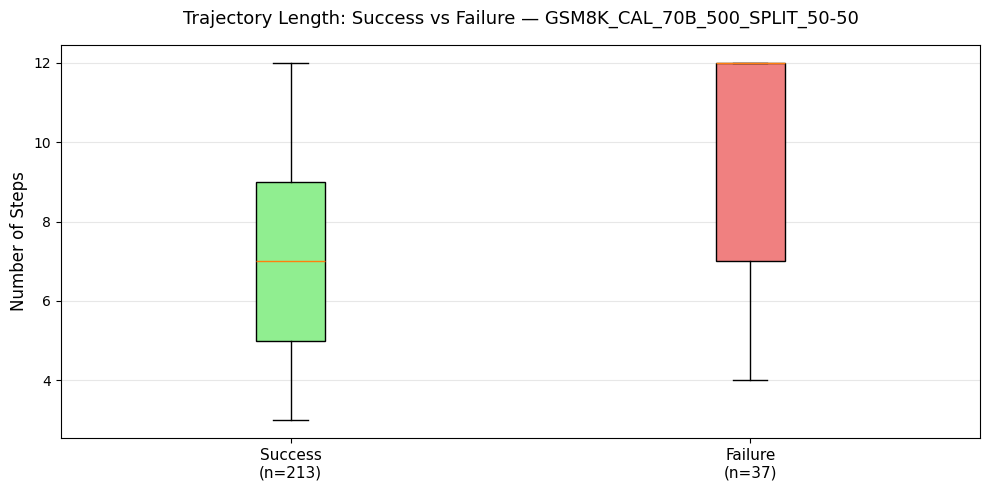


✅ All analysis plots saved!


In [32]:
# ============================================================================
# 10. SUCCESS vs FAILURE ANALYSIS
# ============================================================================
print(f"\n=== SUCCESS VS FAILURE ===")
success_n_steps = [t['n_steps'] for t in trajectories if t.get('task_success', False)]
failure_n_steps = [t['n_steps'] for t in trajectories if not t.get('task_success', False)]

print(f"Successful trajectories: {len(success_n_steps)} ({100*len(success_n_steps)/len(trajectories):.1f}%)")
print(f"  Mean steps: {np.mean(success_n_steps):.2f}")
print(f"Failed trajectories: {len(failure_n_steps)} ({100*len(failure_n_steps)/len(trajectories):.1f}%)")
print(f"  Mean steps: {np.mean(failure_n_steps):.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
data_to_plot = [success_n_steps, failure_n_steps]
bp = ax.boxplot(data_to_plot, labels=['Success', 'Failure'], patch_artist=True)

colors = ['lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel("Number of Steps", fontsize=12)
ax.set_title(f"Trajectory Length: Success vs Failure — {EXPERIMENT.upper()}", fontsize=13, pad=15)
ax.grid(True, alpha=0.3, axis='y')

# Add sample counts to labels
ax.set_xticklabels([f'Success\n(n={len(success_n_steps)})', f'Failure\n(n={len(failure_n_steps)})'], fontsize=11)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/success_vs_failure.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"\n✅ All analysis plots saved!")